# DD Startup Results Comparison Tool

This notebook provides a flexible interface to compare results across multiple HDF5 analysis files.

## Features
- Load and compare any number of analysis files
- Multiple comparison modes:
  - **Best N**: Top N combinations by chosen metric
  - **Worst N**: Bottom N combinations by chosen metric
  - **Quartile Analysis**: Statistics for top/bottom quartiles
  - **Random Sample**: Random selection for distribution analysis
- **Vector outputs**: Automatically detects and plots time-dependent outputs (P_aux, N_ofc, P_DT, etc.)
- Excel export with separate sheets per file
- Summary statistics across all files

## Quick Start
1. Configure your files and analysis mode in Section 1
2. Run all cells
3. Find your Excel comparison in the `outputs/` directory
4. Find vector output plots in `outputs/vector_plots_{metric}/` directories

## Section 1: Configuration

Configure your analysis parameters here.

### 🆕 Modular Approach

This allows you to extract:
- Best values from each quartile
- Median values from each quartile  
- Top N best/worst overall
- Specific percentiles
- And more!

**Example use case:** "I want the best value and median from each quartile"
```python
ANALYSIS_STRATEGIES = [
    {'name': 'Q1_Best', 'type': 'quartile_best', 'quartile': 'q1'},
    {'name': 'Q1_Median', 'type': 'quartile_median', 'quartile': 'q1'},
    {'name': 'Q2_Best', 'type': 'quartile_best', 'quartile': 'q2'},
    {'name': 'Q2_Median', 'type': 'quartile_median', 'quartile': 'q2'},
    # ... etc
]
```

The notebook will process all strategies for each file and create comprehensive Excel sheets for comparison.


In [5]:
# ============================================================================
# CONFIGURATION
# ============================================================================

# Files to analyze (folders or .h5 files)
# If empty, will use the latest file found in outputs/
FILES_TO_ANALYZE = [
    '20251112_105650_parametric_T_seeded',  # Folder name (relative to outputs/)
    '20251111_232630_parametric_lump',  # Folder name
    # 'path/to/specific/file.h5',  # Or specific file path
]

# Metrics to use for comparison (can be a single string or a list)
# Single metric: COMPARISON_METRICS = 'unrealized_profits'
# Multiple metrics: COMPARISON_METRICS = ['unrealized_profits', 't_startup', 'Q_DD']
# Common options: 'unrealized_profits', 't_startup', 'Q_DD', 'E_lost', 'TBR_DDn', etc.
COMPARISON_METRICS = ['unrealized_profits', 't_startup']

# ============================================================================
# ANALYSIS STRATEGIES
# ============================================================================
# Define multiple extraction strategies to run on each file.
# Each strategy is a dict with 'name', 'type', and type-specific parameters.
# 
# Available types:
#   - 'best_n': Extract top N best (lowest) values
#   - 'worst_n': Extract top N worst (highest) values
#   - 'quartile_best': Extract best value from specified quartile
#   - 'quartile_median': Extract median value from specified quartile
#   - 'quartile_worst': Extract worst value from specified quartile
#   - 'quartile_sample': Extract N random samples from specified quartile
#   - 'percentile': Extract value at specific percentile
#   - 'random': Extract N random samples from entire dataset

ANALYSIS_STRATEGIES = [
    # Best overall
    #{'name': 'Top_10_Best', 'type': 'best_n', 'n': 10},
    
    # Best and Median from each quartile
    {'name': 'Q1_Best', 'type': 'quartile_best', 'quartile': 'q1'},
    {'name': 'Q1_Median', 'type': 'quartile_median', 'quartile': 'q1'},
    {'name': 'Q2_Best', 'type': 'quartile_best', 'quartile': 'q2'},
    {'name': 'Q2_Median', 'type': 'quartile_median', 'quartile': 'q2'},
    {'name': 'Q3_Best', 'type': 'quartile_best', 'quartile': 'q3'},
    {'name': 'Q3_Median', 'type': 'quartile_median', 'quartile': 'q3'},
    {'name': 'Q4_Best', 'type': 'quartile_best', 'quartile': 'q4'},
    {'name': 'Q4_Median', 'type': 'quartile_median', 'quartile': 'q4'},
    
    # Optional: Add more strategies as needed
    # {'name': 'Top_5_Worst', 'type': 'worst_n', 'n': 5},
    # {'name': 'P95', 'type': 'percentile', 'percentile': 95},
]

# ============================================================================
# OUTPUT CONFIGURATION
# ============================================================================

# Display options
SHOW_ALL_OUTPUTS = True  # Show all output variables in console
SHOW_ALL_INPUTS = True   # Show all input parameters in console
MAX_DISPLAY = 3          # Max combinations to display per strategy in console

# Failed simulations export
EXPORT_FAILED_SIMS = True  # Set to False to skip exporting failed simulations
MAX_FAILED_TO_EXPORT = 10000  # Maximum number of failed sims to export per file

# ============================================================================
# PROCESS CONFIGURATION
# ============================================================================

# Convert COMPARISON_METRICS to list if single string
if isinstance(COMPARISON_METRICS, str):
    COMPARISON_METRICS = [COMPARISON_METRICS]

# Generate file labels for Excel naming
file_labels = []
for file_path in FILES_TO_ANALYZE:
    # Extract meaningful name from path
    if '/' in file_path or '\\' in file_path:
        name = file_path.split('/')[-1].split('\\')[-1]
    else:
        name = file_path
    
    # Clean up name (remove timestamps, common prefixes)
    # Example: '20251109_113840_parametric_lump' -> 'lump'
    if 'parametric' in name.lower():
        parts = name.lower().split('parametric')
        if len(parts) > 1:
            label = parts[1].strip('_').replace('_', '')
        else:
            label = name.replace('parametric', '').strip('_').replace('_', '')
    else:
        label = name.split('_')[-1] if '_' in name else name
    
    file_labels.append(label)

print("✅ Configuration loaded")
print(f"   Strategies: {len(ANALYSIS_STRATEGIES)} defined")
print(f"   Metrics: {', '.join(COMPARISON_METRICS)}")
print(f"   Strategy examples: {', '.join([s['name'] for s in ANALYSIS_STRATEGIES[:3]])}{'...' if len(ANALYSIS_STRATEGIES) > 3 else ''}")
print(f"   Files: {len(FILES_TO_ANALYZE) if FILES_TO_ANALYZE else 'Using latest'}")
if len(COMPARISON_METRICS) > 1:
    print(f"   Output: {len(COMPARISON_METRICS)} Excel files will be created (one per metric)")


✅ Configuration loaded
   Strategies: 8 defined
   Metrics: unrealized_profits, t_startup
   Strategy examples: Q1_Best, Q1_Median, Q2_Best...
   Files: 2
   Output: 2 Excel files will be created (one per metric)


## Section 2: Setup and Imports

Import required libraries and helper functions.

In [2]:
# ============================================================================
# IMPORTS
# ============================================================================

import sys
from pathlib import Path
import pandas as pd
import numpy as np

# Add parent directory to path for imports
parent_dir = Path.cwd().parent
if str(parent_dir) not in sys.path:
    sys.path.insert(0, str(parent_dir))

from ddstartup.postprocessing.postprocess_functions import (
    find_latest_h5_file,
    get_input_parameters
)

# Check for openpyxl
import openpyxl

print("✅ Imports complete")

✅ Imports complete


## Section 3: Helper Functions

Define functions for data loading and processing.

In [3]:
# ============================================================================
# HELPER FUNCTIONS
# ============================================================================

def load_h5_efficiently(h5_file, target_metric):
    """
    Load HDF5 file efficiently - only loads the target metric initially,
    then loads full data only for selected rows.
    
    Returns:
        tuple: (full_df, metric_series, total_rows)
    """
    import h5py
    import hdf5plugin
    
    with h5py.File(h5_file, 'r') as f:
        # Get total rows from file attributes
        total_rows = f.attrs.get('total_combinations', None)
        if total_rows is None:
            # Try alternative attribute name
            total_rows = f.attrs.get('n_samples', None)
        if total_rows is None:
            raise ValueError(f"Could not find total row count in {h5_file.name}")
        
        # Check if metric exists (datasets are at top level)
        if target_metric not in f.keys():
            available = list(f.keys())
            raise ValueError(f"Metric '{target_metric}' not found in {h5_file.name}. Available: {available[:10]}")
        
        # Load only the target metric for initial filtering
        metric_data = f[target_metric][:]
    
    return None, metric_data, total_rows


def load_selected_rows(h5_file, indices):
    """
    Load specific rows from HDF5 file.
    Loads both scalar (1-D) and vector (2-D) datasets.
    
    Args:
        h5_file: Path to HDF5 file
        indices: Array of row indices to load
    
    Returns:
        tuple: (scalar_df, vector_dict)
            - scalar_df: DataFrame with scalar values
            - vector_dict: Dictionary {param_name: 2D array of shape (n_rows, vector_length)}
    """
    import h5py
    import hdf5plugin
    
    scalar_data = {}
    vector_data = {}
    
    with h5py.File(h5_file, 'r') as f:
        # Load all datasets
        for key in f.keys():
            if isinstance(f[key], h5py.Dataset):
                dataset = f[key]
                
                if len(dataset.shape) == 1:
                    # Scalar dataset (one value per row)
                    scalar_data[key] = dataset[:][indices]
                    
                elif len(dataset.shape) == 2:
                    # Vector dataset (time series, multiple values per row)
                    vector_data[key] = dataset[indices, :]
    
    scalar_df = pd.DataFrame(scalar_data)
    return scalar_df, vector_data


def apply_strategy(metric_data, strategy):
    """
    Apply an analysis strategy to extract specific indices.
    
    Args:
        metric_data: Array of metric values
        strategy: Dictionary with 'name', 'type', and type-specific parameters
    
    Returns:
        tuple: (indices, description)
    """
    strategy_type = strategy['type']
    total_rows = len(metric_data)
    
    if strategy_type == 'best_n':
        n = strategy['n']
        n = min(n, total_rows)
        indices = np.argpartition(metric_data, n-1)[:n]
        indices = indices[np.argsort(metric_data[indices])]
        desc = f"Top {n} best (lowest) values"
        
    elif strategy_type == 'worst_n':
        n = strategy['n']
        n = min(n, total_rows)
        indices = np.argpartition(metric_data, -n)[-n:]
        indices = indices[np.argsort(metric_data[indices])[::-1]]
        desc = f"Top {n} worst (highest) values"
        
    elif strategy_type == 'quartile_best':
        quartile = strategy['quartile']
        q_indices = get_quartile_indices(metric_data, quartile)
        best_in_q = np.argmin(metric_data[q_indices])
        indices = np.array([q_indices[best_in_q]])
        desc = f"Best value in {quartile.upper()}"
        
    elif strategy_type == 'quartile_median':
        quartile = strategy['quartile']
        q_indices = get_quartile_indices(metric_data, quartile)
        q_sorted_indices = q_indices[np.argsort(metric_data[q_indices])]
        median_idx = len(q_sorted_indices) // 2
        indices = np.array([q_sorted_indices[median_idx]])
        desc = f"Median value in {quartile.upper()}"
        
    elif strategy_type == 'quartile_worst':
        quartile = strategy['quartile']
        q_indices = get_quartile_indices(metric_data, quartile)
        worst_in_q = np.argmax(metric_data[q_indices])
        indices = np.array([q_indices[worst_in_q]])
        desc = f"Worst value in {quartile.upper()}"
        
    elif strategy_type == 'quartile_sample':
        quartile = strategy['quartile']
        n = strategy.get('n', 10)
        q_indices = get_quartile_indices(metric_data, quartile)
        if len(q_indices) > n:
            np.random.seed(42)
            sampled = np.random.choice(q_indices, size=n, replace=False)
            indices = sampled[np.argsort(metric_data[sampled])]
        else:
            indices = q_indices[np.argsort(metric_data[q_indices])]
        desc = f"Sample of {len(indices)} from {quartile.upper()}"
        
    elif strategy_type == 'percentile':
        percentile = strategy['percentile']
        p_value = np.percentile(metric_data, percentile)
        # Find closest value to percentile
        idx = np.argmin(np.abs(metric_data - p_value))
        indices = np.array([idx])
        desc = f"Value at {percentile}th percentile"
        
    elif strategy_type == 'random':
        n = strategy['n']
        np.random.seed(42)
        indices = np.random.choice(total_rows, size=min(n, total_rows), replace=False)
        indices = indices[np.argsort(metric_data[indices])]
        desc = f"Random sample of {len(indices)}"
        
    else:
        raise ValueError(f"Unknown strategy type: {strategy_type}")
    
    return indices, desc


def get_quartile_indices(metric_data, quartile):
    """
    Get indices for a specific quartile.
    
    Args:
        metric_data: Array of metric values
        quartile: 'q1', 'q2', 'q3', or 'q4'
    
    Returns:
        Array of indices in the specified quartile
    """
    total_rows = len(metric_data)
    sorted_indices = np.argsort(metric_data)
    
    q_ranges = {
        'q1': (0, total_rows // 4),
        'q2': (total_rows // 4, total_rows // 2),
        'q3': (total_rows // 2, 3 * total_rows // 4),
        'q4': (3 * total_rows // 4, total_rows)
    }
    
    start, end = q_ranges[quartile]
    return sorted_indices[start:end]


def format_value_for_display(value, param_name=''):
    """
    Format a value for console display.
    """
    if param_name == 't_startup':
        years = value / (365.25 * 24 * 3600)
        return f"{years:.4g} days ({value:.4g} s)"
    elif isinstance(value, (int, np.integer)):
        return f"{value:,}"
    elif isinstance(value, (float, np.floating)):
        return f"{value:.4g}"
    else:
        return str(value)


print("✅ Helper functions defined")

✅ Helper functions defined


## Section 4: File Collection

Collect and validate HDF5 files to analyze.

In [4]:
# ============================================================================
# COLLECT FILES
# ============================================================================

outputs_dir = Path.cwd()  # We're already in outputs/
h5_files = []

if FILES_TO_ANALYZE:
    print(f"Collecting files from configuration...")
    for file_path in FILES_TO_ANALYZE:
        p = Path(file_path)
        
        # Handle relative paths (relative to outputs/)
        if not p.is_absolute():
            p = outputs_dir / p
        
        if p.is_dir():
            # Find H5 files in directory
            h5_in_dir = list(p.glob('*.h5'))
            if h5_in_dir:
                h5_files.extend(h5_in_dir)
                print(f"  ✅ Found {len(h5_in_dir)} file(s) in {p.name}")
            else:
                print(f"  ⚠️  No .h5 files in {p.name}")
        elif p.suffix == '.h5' and p.exists():
            h5_files.append(p)
            print(f"  ✅ Added {p.name}")
        else:
            print(f"  ⚠️  Invalid or missing: {file_path}")
else:
    # Use latest file
    print("No files specified, searching for latest...")
    latest = find_latest_h5_file(outputs_dir)
    if latest:
        h5_files = [latest]
        print(f"  ✅ Using latest: {latest.name}")
    else:
        print("  ❌ No HDF5 files found in outputs/")

if not h5_files:
    raise ValueError("No HDF5 files to analyze. Check your FILES_TO_ANALYZE configuration.")

print(f"\n{'='*80}")
print(f"📂 Ready to analyze {len(h5_files)} file(s)")
print(f"{'='*80}")

  ✅ Found 1 file(s) in 20251112_105650_parametric_T_seeded
  ✅ Found 1 file(s) in 20251111_232630_parametric_lump

📂 Ready to analyze 2 file(s)


## Section 5: Analysis and Comparison

Process each file and extract comparison data.

In [5]:
# ============================================================================
# PROCESS FILES - LOOP OVER METRICS
# ============================================================================

# Store results for all metrics: {metric_name: {file_name: {strategy_name: df}}}
all_metrics_results = {}
all_metrics_statistics = {}
all_metrics_metadata = {}
all_metrics_vectors = {}  # Store vector data separately

for COMPARISON_METRIC in COMPARISON_METRICS:
    
    print(f"\n{'#'*80}")
    print(f"# PROCESSING METRIC: {COMPARISON_METRIC}")
    print(f"{'#'*80}")
    
    all_results = {}  # Store DataFrames: {file_name: {strategy_name: df}}
    all_statistics = {}  # Store statistics: {file_name: {strategy_name: stats}}
    all_vectors = {}  # Store vector data: {file_name: {strategy_name: {param: array}}}
    file_metadata = {}  # Store metadata
    
    for h5_file in h5_files:
        file_name = h5_file.stem
        
        print(f"\n{'='*80}")
        print(f"📁 Processing: {h5_file.name}")
        print(f"{'='*80}")
        
        try:
            # Load metric data AND success flag
            print(f"Loading metric '{COMPARISON_METRIC}' and filtering successful runs...")
            
            import h5py
            import hdf5plugin
            
            with h5py.File(h5_file, 'r') as f:
                total_rows = f.attrs.get('total_combinations', f.attrs.get('n_samples', None))
                
                # Check if metric exists
                if COMPARISON_METRIC not in f.keys():
                    available = list(f.keys())
                    raise ValueError(f"Metric '{COMPARISON_METRIC}' not found. Available: {available[:10]}")
                
                # Load metric and success flag
                metric_data = f[COMPARISON_METRIC][:]
                
                # Load sol_success if available
                if 'sol_success' in f.keys():
                    success_flag = f['sol_success'][:]
                    # Filter to only successful runs
                    valid_mask = success_flag.astype(bool)
                    valid_indices = np.where(valid_mask)[0]
                    
                    if len(valid_indices) == 0:
                        print(f"  ⚠️  No successful runs found in this file!")
                        continue
                    
                    print(f"  Found {total_rows:,} total combinations")
                    print(f"  Filtered to {len(valid_indices):,} successful runs ({100*len(valid_indices)/total_rows:.1f}%)")
                    
                    # Create filtered metric data (only successful runs)
                    filtered_metric_data = metric_data[valid_indices]
                else:
                    # No success flag, use all data
                    print(f"  Found {total_rows:,} total combinations (no sol_success flag)")
                    valid_indices = np.arange(total_rows)
                    filtered_metric_data = metric_data
            
            # Initialize storage for this file
            all_results[file_name] = {}
            all_statistics[file_name] = {}
            all_vectors[file_name] = {}
            file_metadata[file_name] = {
                'total_rows': total_rows,
                'successful_rows': len(valid_indices)
            }
            
            # Use configured strategies
            strategies = ANALYSIS_STRATEGIES
            print(f"  Running {len(strategies)} analysis strategies...")
            
            # Process each strategy
            for strategy in strategies:
                strategy_name = strategy['name']
                
                try:
                    print(f"\n  🔍 Strategy: {strategy_name}")
                    
                    # Get indices based on strategy (applied to filtered data)
                    filtered_indices, mode_desc = apply_strategy(filtered_metric_data, strategy)
                    print(f"     Selection: {mode_desc} ({len(filtered_indices)} rows)")
                    
                    # Map back to original indices
                    original_indices = valid_indices[filtered_indices]
                    
                    # Load only selected rows (both scalars and vectors)
                    df, vector_data = load_selected_rows(h5_file, original_indices)
                    
                    # Report vector outputs found
                    if vector_data:
                        print(f"     Vector outputs found: {list(vector_data.keys())}")
                    
                    # Verify we got successful runs
                    if 'sol_success' in df.columns:
                        n_failed = (~df['sol_success'].astype(bool)).sum()
                        if n_failed > 0:
                            print(f"     ⚠️  WARNING: {n_failed} failed runs in selection (should be 0!)")
                    
                    # Add metadata columns
                    df.insert(0, 'Strategy', strategy_name)
                    df.insert(1, 'Rank_in_Strategy', range(1, len(df) + 1))
                    df.insert(2, 'Source_File', file_name)
                    
                    # Get input/output parameters (only once per file)
                    if 'input_params' not in file_metadata[file_name]:
                        input_params = get_input_parameters(df, COMPARISON_METRIC, filename=str(h5_file))
                        output_params = [col for col in df.columns if col not in input_params + ['Strategy', 'Rank_in_Strategy', 'Source_File']]
                        file_metadata[file_name]['input_params'] = input_params
                        file_metadata[file_name]['output_params'] = output_params
                    else:
                        input_params = file_metadata[file_name]['input_params']
                        output_params = file_metadata[file_name]['output_params']
                    
                    # Store results
                    all_results[file_name][strategy_name] = df
                    all_vectors[file_name][strategy_name] = vector_data
                    
                    # Calculate statistics
                    stats = {
                        'min': df[COMPARISON_METRIC].min(),
                        'max': df[COMPARISON_METRIC].max(),
                        'mean': df[COMPARISON_METRIC].mean(),
                        'median': df[COMPARISON_METRIC].median(),
                        'std': df[COMPARISON_METRIC].std() if len(df) > 1 else 0.0,
                        'count': len(df),
                        'description': mode_desc
                    }
                    all_statistics[file_name][strategy_name] = stats
                    
                    # Display preview (only first few strategies to avoid clutter)
                    strategy_idx = strategies.index(strategy)
                    if strategy_idx < 3:  # Show first 3 strategies
                        print(f"     Stats: min={stats['min']:.6g}, max={stats['max']:.6g}, mean={stats['mean']:.6g}")
                        
                        n_display = min(MAX_DISPLAY, len(df))
                        for idx in range(n_display):
                            row = df.iloc[idx]
                            print(f"       #{idx+1}: {COMPARISON_METRIC}={row[COMPARISON_METRIC]:.6g}")
                    elif strategy_idx == 3:
                        print(f"     ... (showing first 3 strategies only, {len(strategies)-3} more processed)")
                    
                except Exception as e:
                    print(f"     ❌ Error with strategy '{strategy_name}': {e}")
                    import traceback
                    traceback.print_exc()
                    continue
            
            print(f"\n✅ File processed successfully ({len(all_results[file_name])} strategies)")
            
        except Exception as e:
            print(f"❌ Error processing {h5_file.name}: {e}")
            import traceback
            traceback.print_exc()
            continue
    
    # Store results for this metric
    all_metrics_results[COMPARISON_METRIC] = all_results
    all_metrics_statistics[COMPARISON_METRIC] = all_statistics
    all_metrics_metadata[COMPARISON_METRIC] = file_metadata
    all_metrics_vectors[COMPARISON_METRIC] = all_vectors
    
    print(f"\n{'='*80}")
    print(f"✅ Metric '{COMPARISON_METRIC}' processed successfully")
    print(f"   Files: {len(all_results)}")
    if len(all_results) > 0:
        total_strategies = sum(len(strategies) for strategies in all_results.values())
        print(f"   Total strategy results: {total_strategies}")
    print(f"{'='*80}")

print(f"\n{'#'*80}")
print(f"✅ ALL METRICS PROCESSED SUCCESSFULLY")
print(f"   Metrics: {len(COMPARISON_METRICS)}")
print(f"   Files per metric: {len(h5_files)}")
print(f"{'#'*80}")


################################################################################
# PROCESSING METRIC: unrealized_profits
################################################################################

📁 Processing: ddstartup_20251112_105650_parametric_T_seeded.h5
Loading metric 'unrealized_profits' and filtering successful runs...
  Found 209,952 total combinations
  Filtered to 185,814 successful runs (88.5%)
  Running 8 analysis strategies...

  🔍 Strategy: Q1_Best
     Selection: Best value in Q1 (1 rows)
     Stats: min=809022, max=809022, mean=809022
       #1: unrealized_profits=809022

  🔍 Strategy: Q1_Median
     Selection: Median value in Q1 (1 rows)
     Stats: min=3.16115e+07, max=3.16115e+07, mean=3.16115e+07
       #1: unrealized_profits=3.16115e+07

  🔍 Strategy: Q2_Best
     Selection: Best value in Q2 (1 rows)
     Stats: min=809022, max=809022, mean=809022
       #1: unrealized_profits=809022

  🔍 Strategy: Q1_Median
     Selection: Median value in Q1 (1 rows)
     

## Section 6: Excel Export

Create comprehensive Excel comparison file.

In [6]:
# ============================================================================
# CREATE EXCEL COMPARISON FILES (ONE PER METRIC)
# ============================================================================

if not all_metrics_results:
    print("❌ No results to export")
else:
    print(f"\n{'='*80}")
    print("📊 Creating Excel comparison files...")
    print(f"{'='*80}\n")
    
    excel_files_created = []
    
    # Loop over each metric
    for COMPARISON_METRIC in COMPARISON_METRICS:
        
        all_results = all_metrics_results[COMPARISON_METRIC]
        all_statistics = all_metrics_statistics[COMPARISON_METRIC]
        file_metadata = all_metrics_metadata[COMPARISON_METRIC]
        all_vectors = all_metrics_vectors.get(COMPARISON_METRIC, {})
        
        if not all_results:
            print(f"⚠️  No results for metric '{COMPARISON_METRIC}', skipping...")
            continue
        
        print(f"\n📋 Creating Excel for metric: {COMPARISON_METRIC}")
        print("-" * 80)
        
        # Generate Excel filename
        # Format: compare_file1_file2_metric.xlsx
        file_parts = '_'.join(file_labels[:3])  # Limit to first 3 files
        if len(file_labels) > 3:
            file_parts += f"_plus{len(file_labels)-3}more"
        
        excel_filename = f"compare_{file_parts}_{COMPARISON_METRIC}.xlsx"
        excel_path = outputs_dir / excel_filename
        
        with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
            
            # Sheet 1: Summary Statistics
            print(f"  Creating Summary sheet...")
            summary_data = []
            for file_name, strategies in all_results.items():
                for strategy_name, df_result in strategies.items():
                    stats = all_statistics[file_name][strategy_name]
                    meta = file_metadata[file_name]
                    summary_data.append({
                        'File': file_name,
                        'Strategy': strategy_name,
                        'Description': stats['description'],
                        'Total_Combinations': meta['total_rows'],
                        'N_Selected': stats['count'],
                        f'{COMPARISON_METRIC}_Min': stats['min'],
                        f'{COMPARISON_METRIC}_Max': stats['max'],
                        f'{COMPARISON_METRIC}_Mean': stats['mean'],
                        f'{COMPARISON_METRIC}_Median': stats['median'],
                        f'{COMPARISON_METRIC}_Std': stats['std'],
                    })
            
            df_summary = pd.DataFrame(summary_data)
            df_summary.to_excel(writer, sheet_name='Summary', index=False)
            print(f"    ✅ Summary sheet created")
            
            # Sheet 2: All Results Combined (with sampled vector values)
            print(f"  Creating All_Results sheet...")
            all_dfs = []
            for file_name, strategies in all_results.items():
                for strategy_name, df_result in strategies.items():
                    df_copy = df_result.copy()
                    
                    # Add sampled vector values (5 points: start, 25%, 50%, 75%, end)
                    if file_name in all_vectors and strategy_name in all_vectors[file_name]:
                        vectors = all_vectors[file_name][strategy_name]
                        
                        # Get time vector if available
                        time_vector = vectors.get('time', None)
                        
                        for param_name, vector_array in vectors.items():
                            if param_name == 'time':
                                continue  # Skip time vector in the loop
                            
                            # vector_array shape: (n_rows, vector_length)
                            n_rows, vector_length = vector_array.shape
                            
                            # Sample 5 points from the vector
                            idx_0 = 0
                            idx_25 = vector_length // 4
                            idx_50 = vector_length // 2
                            idx_75 = 3 * vector_length // 4
                            idx_100 = vector_length - 1
                            
                            df_copy[f'{param_name}_t0'] = vector_array[:, idx_0]
                            df_copy[f'{param_name}_t25'] = vector_array[:, idx_25]
                            df_copy[f'{param_name}_t50'] = vector_array[:, idx_50]
                            df_copy[f'{param_name}_t75'] = vector_array[:, idx_75]
                            df_copy[f'{param_name}_t100'] = vector_array[:, idx_100]
                        
                        # Add time vector columns (same for all rows of this strategy)
                        if time_vector is not None:
                            # time_vector shape: (n_rows, vector_length)
                            # Use first row as reference (should be same for all)
                            time_ref = time_vector[0, :]
                            vector_length = len(time_ref)
                            idx_0 = 0
                            idx_25 = vector_length // 4
                            idx_50 = vector_length // 2
                            idx_75 = 3 * vector_length // 4
                            idx_100 = vector_length - 1
                            
                            df_copy['time_t0'] = time_ref[idx_0]
                            df_copy['time_t25'] = time_ref[idx_25]
                            df_copy['time_t50'] = time_ref[idx_50]
                            df_copy['time_t75'] = time_ref[idx_75]
                            df_copy['time_t100'] = time_ref[idx_100]
                    
                    all_dfs.append(df_copy)
            
            if all_dfs:
                df_all = pd.concat(all_dfs, ignore_index=True)
                # Sort by metric for easy comparison
                df_all = df_all.sort_values(COMPARISON_METRIC)
                df_all.insert(0, 'Global_Rank', range(1, len(df_all) + 1))
                df_all.to_excel(writer, sheet_name='All_Results', index=False)
                print(f"    ✅ All_Results sheet created")
                
                # Report vector columns added
                vector_cols = [col for col in df_all.columns if any(col.endswith(suffix) for suffix in ['_t0', '_t25', '_t50', '_t75', '_t100'])]
                if vector_cols:
                    print(f"    ℹ️  Added vector sampled values: {len(vector_cols)} columns")
            
            # Sheets 3-N: Per-File sheets (all strategies for each file)
            print(f"  Creating per-file sheets...")
            for file_name, strategies in all_results.items():
                # Combine all strategies for this file
                file_dfs = []
                for strategy_name, df_result in strategies.items():
                    df_copy = df_result.copy()
                    
                    # Add sampled vector values
                    if file_name in all_vectors and strategy_name in all_vectors[file_name]:
                        vectors = all_vectors[file_name][strategy_name]
                        time_vector = vectors.get('time', None)
                        
                        for param_name, vector_array in vectors.items():
                            if param_name == 'time':
                                continue
                            
                            n_rows, vector_length = vector_array.shape
                            
                            idx_0 = 0
                            idx_25 = vector_length // 4
                            idx_50 = vector_length // 2
                            idx_75 = 3 * vector_length // 4
                            idx_100 = vector_length - 1
                            
                            df_copy[f'{param_name}_t0'] = vector_array[:, idx_0]
                            df_copy[f'{param_name}_t25'] = vector_array[:, idx_25]
                            df_copy[f'{param_name}_t50'] = vector_array[:, idx_50]
                            df_copy[f'{param_name}_t75'] = vector_array[:, idx_75]
                            df_copy[f'{param_name}_t100'] = vector_array[:, idx_100]
                        
                        if time_vector is not None:
                            time_ref = time_vector[0, :]
                            vector_length = len(time_ref)
                            idx_0 = 0
                            idx_25 = vector_length // 4
                            idx_50 = vector_length // 2
                            idx_75 = 3 * vector_length // 4
                            idx_100 = vector_length - 1
                            
                            df_copy['time_t0'] = time_ref[idx_0]
                            df_copy['time_t25'] = time_ref[idx_25]
                            df_copy['time_t50'] = time_ref[idx_50]
                            df_copy['time_t75'] = time_ref[idx_75]
                            df_copy['time_t100'] = time_ref[idx_100]
                    
                    file_dfs.append(df_copy)
                
                if file_dfs:
                    df_file = pd.concat(file_dfs, ignore_index=True)
                    df_file = df_file.sort_values([COMPARISON_METRIC])
                    
                    # Truncate sheet name if needed (Excel limit: 31 chars)
                    sheet_name = file_name[:31] if len(file_name) > 31 else file_name
                    df_file.to_excel(writer, sheet_name=sheet_name, index=False)
                    print(f"    ✅ Sheet '{sheet_name}' created ({len(strategies)} strategies)")
            
            # Additional sheets: Per-Strategy sheets (all files for each strategy)
            if len(all_results) > 1:
                print(f"  Creating per-strategy sheets...")
                # Get all unique strategy names
                all_strategy_names = set()
                for strategies in all_results.values():
                    all_strategy_names.update(strategies.keys())
                
                for strategy_name in sorted(all_strategy_names):
                    strategy_dfs = []
                    for file_name, strategies in all_results.items():
                        if strategy_name in strategies:
                            df_copy = strategies[strategy_name].copy()
                            
                            # Add sampled vector values
                            if file_name in all_vectors and strategy_name in all_vectors[file_name]:
                                vectors = all_vectors[file_name][strategy_name]
                                time_vector = vectors.get('time', None)
                                
                                for param_name, vector_array in vectors.items():
                                    if param_name == 'time':
                                        continue
                                    
                                    n_rows, vector_length = vector_array.shape
                                    
                                    idx_0 = 0
                                    idx_25 = vector_length // 4
                                    idx_50 = vector_length // 2
                                    idx_75 = 3 * vector_length // 4
                                    idx_100 = vector_length - 1
                                    
                                    df_copy[f'{param_name}_t0'] = vector_array[:, idx_0]
                                    df_copy[f'{param_name}_t25'] = vector_array[:, idx_25]
                                    df_copy[f'{param_name}_t50'] = vector_array[:, idx_50]
                                    df_copy[f'{param_name}_t75'] = vector_array[:, idx_75]
                                    df_copy[f'{param_name}_t100'] = vector_array[:, idx_100]
                                
                                if time_vector is not None:
                                    time_ref = time_vector[0, :]
                                    vector_length = len(time_ref)
                                    idx_0 = 0
                                    idx_25 = vector_length // 4
                                    idx_50 = vector_length // 2
                                    idx_75 = 3 * vector_length // 4
                                    idx_100 = vector_length - 1
                                    
                                    df_copy['time_t0'] = time_ref[idx_0]
                                    df_copy['time_t25'] = time_ref[idx_25]
                                    df_copy['time_t50'] = time_ref[idx_50]
                                    df_copy['time_t75'] = time_ref[idx_75]
                                    df_copy['time_t100'] = time_ref[idx_100]
                            
                            strategy_dfs.append(df_copy)
                    
                    if strategy_dfs:
                        df_strategy = pd.concat(strategy_dfs, ignore_index=True)
                        df_strategy = df_strategy.sort_values(COMPARISON_METRIC)
                        
                        # Truncate sheet name (prefix with 'S_' for strategy)
                        sheet_name = f"S_{strategy_name}"[:31]
                        df_strategy.to_excel(writer, sheet_name=sheet_name, index=False)
                        print(f"    ✅ Sheet '{sheet_name}' created")
        
        excel_files_created.append(excel_filename)
        print(f"\n  ✅ Excel file created: {excel_filename}")
    
    print(f"\n{'='*80}")
    print(f"✅ ALL EXCEL FILES CREATED")
    print(f"{'='*80}")
    print(f"\n📁 Files created ({len(excel_files_created)}):")
    for filename in excel_files_created:
        print(f"   - {filename}")
    
    print(f"\n📋 Each file includes:")
    print(f"   - Summary: Statistics for all files and strategies")
    print(f"   - All_Results: All data combined and ranked by metric")
    print(f"   - Per-file sheets: All strategies for each file")
    if len(all_results) > 1:
        print(f"   - Per-strategy sheets: Cross-file comparison for each strategy")
    
    # Check if vector data was included
    has_vectors = any(all_vectors.get(metric, {}) for metric in COMPARISON_METRICS)
    if has_vectors:
        print(f"\n📊 Vector outputs included as sampled values (5 points):")
        print(f"   - {{param}}_t0: Initial value (t=0%)")
        print(f"   - {{param}}_t25: Value at 25% of simulation time")
        print(f"   - {{param}}_t50: Value at 50% of simulation time")
        print(f"   - {{param}}_t75: Value at 75% of simulation time")
        print(f"   - {{param}}_t100: Final value (t=100%)")
        print(f"   - time_t0 through time_t100: Corresponding time values")
        print(f"   - See vector_plots_{{metric}}/ for detailed time series plots")
    
    print(f"\n💡 Tip: Use filters and pivot tables in Excel for deeper analysis!")



📊 Creating Excel comparison files...


📋 Creating Excel for metric: unrealized_profits
--------------------------------------------------------------------------------
  Creating Summary sheet...
    ✅ Summary sheet created
  Creating All_Results sheet...


    ✅ All_Results sheet created
    ℹ️  Added vector sampled values: 55 columns
  Creating per-file sheets...
    ✅ Sheet 'ddstartup_20251112_105650_param' created (8 strategies)
    ✅ Sheet 'ddstartup_20251111_232630_param' created (8 strategies)
  Creating per-strategy sheets...
    ✅ Sheet 'S_Q1_Best' created
    ✅ Sheet 'S_Q1_Median' created
    ✅ Sheet 'S_Q2_Best' created
    ✅ Sheet 'S_Q2_Median' created
    ✅ Sheet 'S_Q3_Best' created
    ✅ Sheet 'S_Q3_Median' created
    ✅ Sheet 'S_Q4_Best' created
    ✅ Sheet 'S_Q4_Median' created

  ✅ Excel file created: compare_tseeded_lump_unrealized_profits.xlsx

📋 Creating Excel for metric: t_startup
--------------------------------------------------------------------------------
  Creating Summary sheet...
    ✅ Summary sheet created
  Creating All_Results sheet...
    ✅ All_Results sheet created
    ℹ️  Added vector sampled values: 55 columns
  Creating per-file sheets...
    ✅ Sheet 'ddstartup_20251112_105650_param' created (8 strategi

## Section 6b: Export Failed Simulations (Optional)

Export input parameters that led to failed simulations for debugging and analysis.

In [7]:
# ============================================================================
# EXPORT FAILED SIMULATIONS
# ============================================================================

if EXPORT_FAILED_SIMS:
    print(f"\n{'='*80}")
    print("🔍 EXPORTING FAILED SIMULATIONS")
    print(f"{'='*80}\n")
    
    failed_files_created = []
    
    for h5_file in h5_files:
        file_name = h5_file.stem
        
        print(f"Processing: {h5_file.name}")
        
        try:
            import h5py
            import hdf5plugin
            
            with h5py.File(h5_file, 'r') as f:
                # Check if sol_success exists
                if 'sol_success' not in f.keys():
                    print(f"  ⚠️  No 'sol_success' flag found, skipping...")
                    continue
                
                # Load success flag
                success_flag = f['sol_success'][:]
                failed_mask = ~success_flag.astype(bool)
                failed_indices = np.where(failed_mask)[0]
                
                total_rows = len(success_flag)
                n_failed = len(failed_indices)
                
                if n_failed == 0:
                    print(f"  ✅ No failed simulations (100% success rate)")
                    continue
                
                print(f"  Found {n_failed:,} failed simulations ({100*n_failed/total_rows:.1f}%)")
                
                # Limit number of failed sims to export
                if n_failed > MAX_FAILED_TO_EXPORT:
                    print(f"  ⚠️  Limiting export to {MAX_FAILED_TO_EXPORT:,} failed simulations (random sample)")
                    np.random.seed(42)
                    failed_indices = np.random.choice(failed_indices, size=MAX_FAILED_TO_EXPORT, replace=False)
                    n_failed = len(failed_indices)
                
                # Load failed rows
                print(f"  Loading {n_failed:,} failed simulation rows...")
                df_failed = load_selected_rows(h5_file, failed_indices)
                
                # Identify input vs output parameters
                # Known outputs (excludes inputs)
                known_outputs = {
                    # Simulation results
                    'E_lost', 'Q_DD', 'Q_DT_eq', 'P_DT_eq',
                    't_startup', 'unrealized_profits',
                    # Metadata
                    'error', 'sol_success', 'linear_index',
                    # Time-dependent outputs (vectors)
                    'N_ifc', 'N_ofc', 'N_st', 'N_T', 'N_D', 'N_He3_plasma',
                    'P_DDn', 'P_DDp', 'P_DT', 'P_fusion', 'P_alpha',
                    'TBE', 'time'
                }
                
                # Get all input columns (those not in known outputs)
                all_input_params = [col for col in df_failed.columns if col not in known_outputs]
                
                # Add error and sol_success for debugging
                export_columns = all_input_params + ['error', 'sol_success']
                
                # Create DataFrame with all input parameters + error message
                df_export = df_failed[export_columns].copy()
                
                # Add metadata
                df_export.insert(0, 'Failed_Index', failed_indices)
                df_export.insert(1, 'Source_File', file_name)
                
                # Decode error messages if they're bytes
                if 'error' in df_export.columns:
                    df_export['error'] = df_export['error'].apply(
                        lambda x: x.decode('utf-8') if isinstance(x, bytes) else str(x)
                    )
                
                # Display which input parameters are being exported
                print(f"  Exporting {len(all_input_params)} input parameters:")
                print(f"    {', '.join(all_input_params)}")
                
                # Generate Excel filename
                file_label = file_labels[h5_files.index(h5_file)] if h5_files.index(h5_file) < len(file_labels) else file_name
                excel_filename = f"failed_simulations_{file_label}.xlsx"
                excel_path = outputs_dir / excel_filename
                
                # Export to Excel
                print(f"  Creating Excel file...")
                with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
                    
                    # Sheet 1: Failed simulations data
                    df_export.to_excel(writer, sheet_name='Failed_Simulations', index=False)
                    
                    # Sheet 2: Summary by error type
                    if 'error' in df_export.columns:
                        error_summary = df_export.groupby('error').size().reset_index(name='Count')
                        error_summary = error_summary.sort_values('Count', ascending=False)
                        error_summary['Percentage'] = 100 * error_summary['Count'] / len(df_export)
                        error_summary.to_excel(writer, sheet_name='Error_Summary', index=False)
                        
                        print(f"  📊 Error types found:")
                        for _, row in error_summary.head(5).iterrows():
                            print(f"     - {row['error']}: {row['Count']:,} ({row['Percentage']:.1f}%)")
                        if len(error_summary) > 5:
                            print(f"     ... ({len(error_summary)-5} more error types)")
                
                failed_files_created.append(excel_filename)
                print(f"  ✅ Exported to: {excel_filename}\n")
                
        except Exception as e:
            print(f"  ❌ Error exporting failed simulations: {e}")
            import traceback
            traceback.print_exc()
            continue
    
    print(f"{'='*80}")
    print(f"✅ FAILED SIMULATIONS EXPORT COMPLETE")
    print(f"{'='*80}")
    
    if failed_files_created:
        print(f"\n📁 Files created ({len(failed_files_created)}):")
        for filename in failed_files_created:
            print(f"   - {filename}")
        print(f"\n💡 Use these files to:")
        print(f"   - Debug why certain parameter combinations failed")
        print(f"   - Identify problematic parameter ranges")
        print(f"   - Adjust constraints or solver settings")
    else:
        print(f"\n✅ No failed simulations found in any files!")

else:
    print(f"\n{'='*80}")
    print("ℹ️  Failed simulations export disabled (set EXPORT_FAILED_SIMS = True to enable)")
    print(f"{'='*80}")



🔍 EXPORTING FAILED SIMULATIONS

Processing: ddstartup_20251112_105650_parametric_T_seeded.h5
  Found 24,138 failed simulations (11.5%)
  ⚠️  Limiting export to 10,000 failed simulations (random sample)
  Loading 10,000 failed simulation rows...
  Found 24,138 failed simulations (11.5%)
  ⚠️  Limiting export to 10,000 failed simulations (random sample)
  Loading 10,000 failed simulation rows...
  Exporting 16 input parameters:
    I_target, P_aux, P_aux_DT_eq, TBR_DDn, TBR_DT, T_i, V_plasma, capacity_factor, eta_th, n_He3, n_tot, price_of_electricity, tau_ifc, tau_ofc, tau_p_He3, tau_p_T
  Creating Excel file...
  Exporting 16 input parameters:
    I_target, P_aux, P_aux_DT_eq, TBR_DDn, TBR_DT, T_i, V_plasma, capacity_factor, eta_th, n_He3, n_tot, price_of_electricity, tau_ifc, tau_ofc, tau_p_He3, tau_p_T
  Creating Excel file...
  📊 Error types found:
     - DT equilibrium not reached within max_simulation_time (10.0 years); Final state at t=3.15e+08s: n_T=1.78e+18 (target=3.50e+19, a

Traceback (most recent call last):
  File "/tmp/ipykernel_10918/396033429.py", line 50, in <module>
    df_failed = load_selected_rows(h5_file, failed_indices)
  File "/tmp/ipykernel_10918/3855042559.py", line 68, in load_selected_rows
    vector_data[key] = dataset[indices, :]
                       ~~~~~~~^^^^^^^^^^^^
  File "h5py/_objects.pyx", line 56, in h5py._objects.with_phil.wrapper
  File "h5py/_objects.pyx", line 57, in h5py._objects.with_phil.wrapper
  File "/home/alessmor/anaconda3/envs/ddstartupenv/lib/python3.13/site-packages/h5py/_hl/dataset.py", line 893, in __getitem__
    selection = sel.select(self.shape, args, dataset=self)
  File "/home/alessmor/anaconda3/envs/ddstartupenv/lib/python3.13/site-packages/h5py/_hl/selections.py", line 82, in select
    return selector.make_selection(args)
           ~~~~~~~~~~~~~~~~~~~~~~~^^^^^^
  File "h5py/_selector.pyx", line 282, in h5py._selector.Selector.make_selection
  File "h5py/_selector.pyx", line 215, in h5py._selector.Sele

## Section 7: Comparison Analysis (Optional)

Additional analysis and visualization of the comparison results.

## Startup Time vs Unrealized Gains Analysis

Load comparison Excel files and visualize the relationship between startup time and unrealized gains.


📊 STARTUP TIME (DAYS) VS UNREALIZED GAINS ANALYSIS

📂 Loading data from: ddstartup_20251112_105650_parametric_T_seeded.h5

📥 Loading t_startup and unrealized_profits...
   Total simulations: 209,952
   Successful simulations: 185,814 (88.5%)

🔽 Filter: MAX_STARTUP_TIME = 1825 days
   Removed 16,056 simulations (8.6%)

🔽 Filter: MAX_UNREALIZED_GAINS = $2 M$
   Removed 169,419 simulations (99.8%)

📊 After all filters: 339 / 185,814 simulations (0.2%)

🔄 Sorting by startup time (days)...
   Startup time range: 10.4209 - 275.4684 days
   Unrealized gains range: $0.8090 - $1.9994 M$

🎯 Optimal Operating Point (minimizing both metrics):
   Index in sorted data: 10
   Startup time: 22.5643 days
   Unrealized gains: $0.8172 M$
   Combined normalized distance: 0.0463

📥 Loading input parameters for optimal point...

✨ Input Parameters at Optimal Point:
   I_target                       = nan
   P_aux                          = 0.0
   P_aux_DT_eq                    = 0.0
   TBR_DDn             

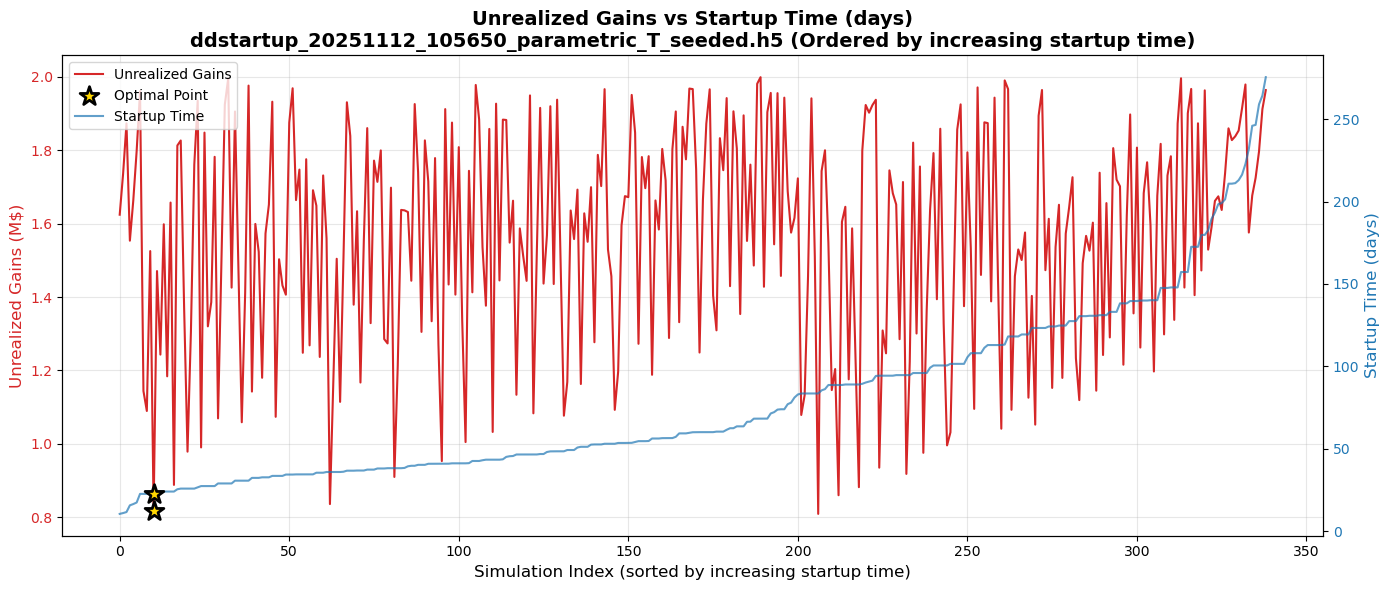


📊 Statistics:
   Total simulations: 339
   Startup time (min): 10.4209 days
   Startup time (max): 275.4684 days
   Startup time (mean): 78.6991 days
   Startup time (median): 59.9708 days
   Unrealized gains (min): $0.8090 M$
   Unrealized gains (max): $1.9994 M$
   Unrealized gains (mean): $1.5647 M$
   Unrealized gains (median): $1.6051 M$

   Correlation (t_startup_days vs unrealized_gains): 0.1332

✅ ANALYSIS COMPLETE


In [8]:
# ============================================================================
# LOAD DATA FROM H5 FILES AND CREATE PLOT (USE DAYS FOR STARTUP TIME)
# ============================================================================
import matplotlib.pyplot as plt
import h5py
import hdf5plugin

# ============================================================================
# FILTERING CONFIGURATION (DAYS)
# ============================================================================
# Set to None to disable filtering, or set a value (in days) to apply the filter
# If MAX_STARTUP_TIME_YEARS exists in the notebook, convert it to days automatically.

MAX_STARTUP_TIME_DAYS = 5 * 365  # default: 5 years -> days

MAX_UNREALIZED_GAINS_M =  2  # in M$

print(f"\n{'='*80}")
print("📊 STARTUP TIME (DAYS) VS UNREALIZED GAINS ANALYSIS")
print(f"{'='*80}\n")

if not h5_files:
    print("❌ No HDF5 files available. Please run the comparison analysis first.")
else:
    # Use the first H5 file (or you can specify which one to use)
    h5_file = h5_files[0]
    
    print(f"📂 Loading data from: {h5_file.name}\n")
    
    try:
        with h5py.File(h5_file, 'r') as f:
            # Check if required datasets exist
            if 't_startup' not in f.keys() or 'unrealized_profits' not in f.keys():
                print("❌ Required datasets not found in HDF5 file.")
                print(f"   Available datasets: {list(f.keys())[:20]}")
            else:
                # Load data
                print("📥 Loading t_startup and unrealized_profits...")
                t_startup = f['t_startup'][:]
                unrealized_profits = f['unrealized_profits'][:]
                
                # Filter for successful simulations only and track indices
                if 'sol_success' in f.keys():
                    success_flag = f['sol_success'][:]
                    valid_mask = success_flag.astype(bool)
                    
                    print(f"   Total simulations: {len(t_startup):,}")
                    print(f"   Successful simulations: {valid_mask.sum():,} ({100*valid_mask.sum()/len(t_startup):.1f}%)")
                    
                    # Track original indices of successful simulations
                    valid_indices = np.where(valid_mask)[0]
                    
                    # Apply filter
                    t_startup = t_startup[valid_mask]
                    unrealized_profits = unrealized_profits[valid_mask]
                else:
                    print(f"   Total simulations: {len(t_startup):,} (no success filter)")
                    # If no success flag, all indices are valid
                    valid_indices = np.arange(len(t_startup))
                
                # Convert units
                t_startup_days = t_startup / (24 * 3600)  # Convert to days
                unrealized_profits_M = unrealized_profits / 1e6  # Convert to M$
                
                # Apply user-defined filters and track which valid indices remain
                filter_mask = np.ones(len(t_startup_days), dtype=bool)
                
                if MAX_STARTUP_TIME_DAYS is not None:
                    before_filter = filter_mask.sum()
                    filter_mask &= (t_startup_days <= MAX_STARTUP_TIME_DAYS)
                    after_filter = filter_mask.sum()
                    removed = before_filter - after_filter
                    pct = 100 * removed / before_filter if before_filter else 0
                    print(f"\n🔽 Filter: MAX_STARTUP_TIME = {MAX_STARTUP_TIME_DAYS} days")
                    print(f"   Removed {removed:,} simulations ({pct:.1f}%)")
                
                if MAX_UNREALIZED_GAINS_M is not None:
                    before_filter = filter_mask.sum()
                    filter_mask &= (unrealized_profits_M <= MAX_UNREALIZED_GAINS_M)
                    after_filter = filter_mask.sum()
                    removed = before_filter - after_filter
                    pct = 100 * removed / before_filter if before_filter else 0
                    print(f"\n🔽 Filter: MAX_UNREALIZED_GAINS = ${MAX_UNREALIZED_GAINS_M} M$")
                    print(f"   Removed {removed:,} simulations ({pct:.1f}%)")
                
                if (MAX_STARTUP_TIME_DAYS is not None) or (MAX_UNREALIZED_GAINS_M is not None):
                    total_before = len(t_startup_days)
                    # Update valid_indices to only include those that pass user filters
                    valid_indices = valid_indices[filter_mask]
                    t_startup_days = t_startup_days[filter_mask]
                    unrealized_profits_M = unrealized_profits_M[filter_mask]
                    kept = len(t_startup_days)
                    pct_kept = 100 * kept / total_before if total_before else 0
                    print(f"\n📊 After all filters: {kept:,} / {total_before:,} simulations ({pct_kept:.1f}%)")
                
                if len(t_startup_days) == 0:
                    print("\n❌ No simulations remaining after filtering!")
                else:
                    print(f"\n🔄 Sorting by startup time (days)...")
                    
                    # Create combined dataframe with indices
                    combined_df = pd.DataFrame({
                        'original_file_index': valid_indices,  # Track original file indices
                        't_startup_days': t_startup_days,
                        'unrealized_gains_M': unrealized_profits_M
                    })
                    
                    # Sort by t_startup_days
                    combined_df_sorted = combined_df.sort_values('t_startup_days').reset_index(drop=True)
                    
                    print(f"   Startup time range: {combined_df_sorted['t_startup_days'].min():.4f} - {combined_df_sorted['t_startup_days'].max():.4f} days")
                    print(f"   Unrealized gains range: ${combined_df_sorted['unrealized_gains_M'].min():.4f} - ${combined_df_sorted['unrealized_gains_M'].max():.4f} M$\n")
                    
                    # Find optimal operating point (minimizing both metrics)
                    # Normalize both metrics to [0, 1] range
                    t_norm = (combined_df_sorted['t_startup_days'] - combined_df_sorted['t_startup_days'].min()) / (combined_df_sorted['t_startup_days'].max() - combined_df_sorted['t_startup_days'].min())
                    u_norm = (combined_df_sorted['unrealized_gains_M'] - combined_df_sorted['unrealized_gains_M'].min()) / (combined_df_sorted['unrealized_gains_M'].max() - combined_df_sorted['unrealized_gains_M'].min())
                    
                    # Calculate combined distance from origin (0, 0) - optimal point minimizes both
                    combined_distance = np.sqrt(t_norm**2 + u_norm**2)
                    optimal_idx = combined_distance.argmin()
                    
                    print(f"🎯 Optimal Operating Point (minimizing both metrics):")
                    print(f"   Index in sorted data: {optimal_idx}")
                    print(f"   Startup time: {combined_df_sorted.iloc[optimal_idx]['t_startup_days']:.4f} days")
                    print(f"   Unrealized gains: ${combined_df_sorted.iloc[optimal_idx]['unrealized_gains_M']:.4f} M$")
                    print(f"   Combined normalized distance: {combined_distance[optimal_idx]:.4f}\n")
                    
                    # Get the original file index for the optimal point
                    original_file_idx = int(combined_df_sorted.iloc[optimal_idx]['original_file_index'])
                    
                    # Load full data for the optimal point to get input parameters
                    print(f"📥 Loading input parameters for optimal point...")
                    with h5py.File(h5_file, 'r') as f:
                        # Load all scalar datasets for this index
                        optimal_params = {}
                        for key in f.keys():
                            if isinstance(f[key], h5py.Dataset) and len(f[key].shape) == 1:
                                optimal_params[key] = f[key][original_file_idx]
                    
                    # Identify input parameters (exclude known outputs)
                    known_outputs = {
                        'E_lost', 'Q_DD', 'Q_DT_eq', 'P_DT_eq',
                        't_startup', 'unrealized_profits',
                        'error', 'sol_success', 'linear_index',
                        'P_DDn', 'P_DDp', 'P_DT', 'P_fusion', 'P_alpha',
                        'TBE',
                    }
                    
                    input_params = {k: v for k, v in optimal_params.items() if k not in known_outputs}
                    
                    print(f"\n✨ Input Parameters at Optimal Point:")
                    print(f"{'='*60}")
                    for param_name, param_value in sorted(input_params.items()):
                        if isinstance(param_value, bytes):
                            param_value = param_value.decode('utf-8')
                        if param_name == 'price_of_electricity': # convert from 1/J to 1/kWh
                            param_value = param_value * 3.6e6  # 1 kWh = 3.6e6 J
                            print(f"   {param_name:30s} = ${param_value:.4f} per kWh")
                        else:
                            print(f"   {param_name:30s} = {param_value}")
                    print(f"{'='*60}\n")
                    
                    # Create the plot (days on right axis)
                    print("📈 Creating dual-axis plot...")
                    
                    fig, ax1 = plt.subplots(figsize=(14, 6))
                    
                    # X-axis: simulation index (after sorting by startup days)
                    x = np.arange(len(combined_df_sorted))
                    
                    # Left y-axis: Unrealized gains in M$
                    color1 = 'tab:red'
                    ax1.set_xlabel('Simulation Index (sorted by increasing startup time)', fontsize=12)
                    ax1.set_ylabel('Unrealized Gains (M$)', color=color1, fontsize=12)
                    line1 = ax1.plot(x, combined_df_sorted['unrealized_gains_M'], 
                                    color=color1, linewidth=1.5, label='Unrealized Gains')
                    ax1.tick_params(axis='y', labelcolor=color1)
                    ax1.grid(True, alpha=0.3)
                    
                    # Right y-axis: Startup time in days
                    ax2 = ax1.twinx()
                    color2 = 'tab:blue'
                    ax2.set_ylabel('Startup Time (days)', color=color2, fontsize=12)
                    line2 = ax2.plot(x, combined_df_sorted['t_startup_days'], 
                                    color=color2, linewidth=1.5, label='Startup Time', alpha=0.7)
                    ax2.tick_params(axis='y', labelcolor=color2)
                    
                    # Highlight the optimal operating point
                    ax1.scatter([optimal_idx], [combined_df_sorted.iloc[optimal_idx]['unrealized_gains_M']], 
                               color='gold', s=200, zorder=5, marker='*', edgecolors='black', linewidths=2,
                               label=f'Optimal Point')
                    ax2.scatter([optimal_idx], [combined_df_sorted.iloc[optimal_idx]['t_startup_days']], 
                               color='gold', s=200, zorder=5, marker='*', edgecolors='black', linewidths=2)
                    
                    # Title
                    plt.title(f'Unrealized Gains vs Startup Time (days)\n{h5_file.name} (Ordered by increasing startup time)', 
                             fontsize=14, fontweight='bold')
                    
                    # Combined legend
                    lines1, labels1 = ax1.get_legend_handles_labels()
                    lines2, labels2 = ax2.get_legend_handles_labels()
                    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)
                    
                    plt.tight_layout()
                    plt.show()
                    
                    # Print statistics (days)
                    print(f"\n📊 Statistics:")
                    print(f"   Total simulations: {len(combined_df_sorted):,}")
                    print(f"   Startup time (min): {combined_df_sorted['t_startup_days'].min():.4f} days")
                    print(f"   Startup time (max): {combined_df_sorted['t_startup_days'].max():.4f} days")
                    print(f"   Startup time (mean): {combined_df_sorted['t_startup_days'].mean():.4f} days")
                    print(f"   Startup time (median): {combined_df_sorted['t_startup_days'].median():.4f} days")
                    print(f"   Unrealized gains (min): ${combined_df_sorted['unrealized_gains_M'].min():.4f} M$")
                    print(f"   Unrealized gains (max): ${combined_df_sorted['unrealized_gains_M'].max():.4f} M$")
                    print(f"   Unrealized gains (mean): ${combined_df_sorted['unrealized_gains_M'].mean():.4f} M$")
                    print(f"   Unrealized gains (median): ${combined_df_sorted['unrealized_gains_M'].median():.4f} M$")
                    
                    # Correlation analysis
                    correlation = combined_df_sorted['t_startup_days'].corr(combined_df_sorted['unrealized_gains_M'])
                    print(f"\n   Correlation (t_startup_days vs unrealized_gains): {correlation:.4f}")
                    
                    print(f"\n{'='*80}")
                    print("✅ ANALYSIS COMPLETE")
                    print(f"{'='*80}")
                
    except Exception as e:
        print(f"❌ Error loading data: {e}")
        import traceback
        traceback.print_exc()

## Equilibrium Power Analysis

Visualize the equilibrium DT fusion power (`P_DT_eq`) for the filtered optimal simulations.


📊 EQUILIBRIUM DT FUSION POWER ANALYSIS - GROSS POWER (P_DT_eq)

📂 Loading data from: ddstartup_20251112_105650_parametric_T_seeded.h5

📥 Loading P_DT_eq, t_startup, and unrealized_profits...
   Total simulations: 209,952
   Successful simulations: 185,814 (88.5%)
   P_DT_eq is a scalar value

   After filters: 339 simulations

📊 Power Statistics (P_DT_eq):
   P_DT_eq (min):    39.24 MW
   P_DT_eq (max):    686.67 MW
   P_DT_eq (mean):   100.97 MW
   P_DT_eq (median): 94.63 MW

🎯 Optimal point power (P_DT_eq): 149.54 MW

📈 Creating consolidated triple-axis plot with trend lines...


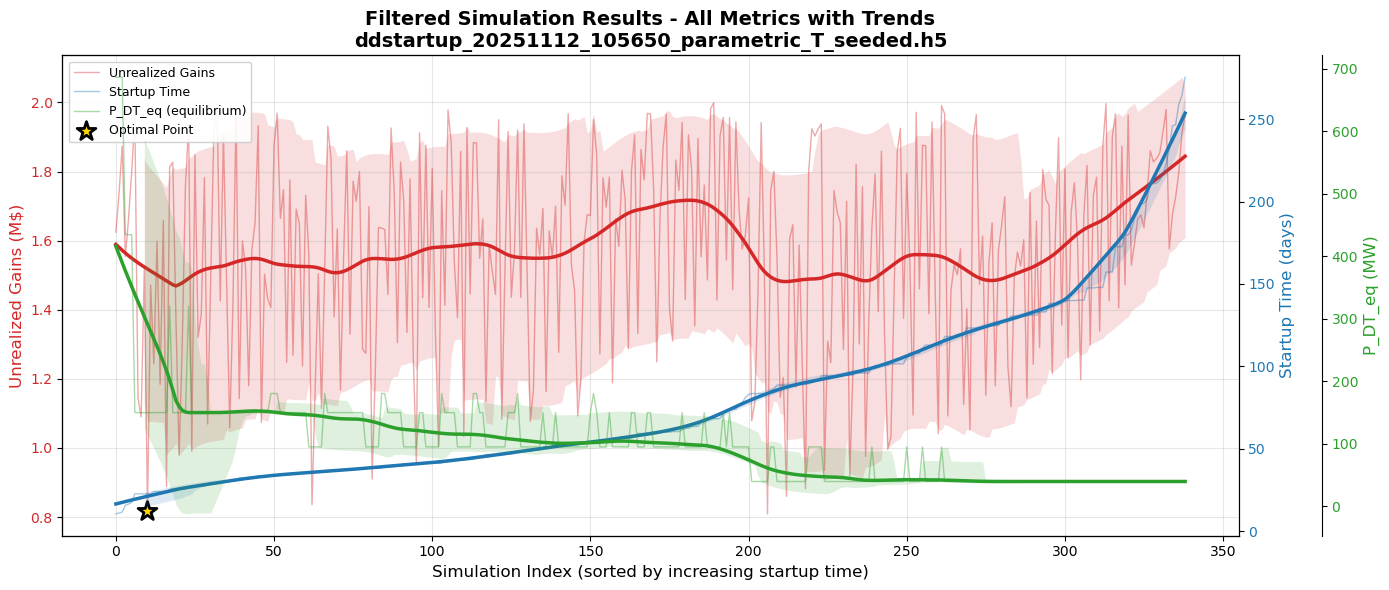


📊 Correlation Analysis:
   P_DT_eq vs t_startup:         -0.5869
   P_DT_eq vs unrealized_gains:  +0.1304

✅ POWER ANALYSIS COMPLETE


In [9]:
# ============================================================================
# EQUILIBRIUM POWER (P_DT_eq) ANALYSIS
# ============================================================================

# Configuration flag: True for P_DT_eq, False for P_DT_eq - P_aux (net power)
USE_GROSS_POWER = True

print(f"\n{'='*80}")
print(f"📊 EQUILIBRIUM DT FUSION POWER ANALYSIS - {'GROSS POWER (P_DT_eq)' if USE_GROSS_POWER else 'NET POWER (P_DT_eq - P_aux)'}")
print(f"{'='*80}\n")

if not h5_files:
    print("❌ No HDF5 files available.")
else:
    h5_file = h5_files[0]
    
    print(f"📂 Loading data from: {h5_file.name}\n")
    
    try:
        with h5py.File(h5_file, 'r') as f:
            # Check if P_DT_eq exists
            if 'P_DT_eq' not in f.keys():
                print("❌ P_DT_eq not found in HDF5 file.")
                print(f"   Available datasets: {list(f.keys())[:20]}")
            else:
                # Load data
                print("📥 Loading P_DT_eq, t_startup, and unrealized_profits...")
                P_DT_eq_data = f['P_DT_eq'][:]
                P_aux_data = f['P_aux'][:]
                t_startup = f['t_startup'][:]
                unrealized_profits = f['unrealized_profits'][:]
                
                # Filter for successful simulations
                if 'sol_success' in f.keys():
                    success_flag = f['sol_success'][:]
                    valid_mask = success_flag.astype(bool)
                    valid_indices = np.where(valid_mask)[0]
                    
                    print(f"   Total simulations: {len(t_startup):,}")
                    print(f"   Successful simulations: {valid_mask.sum():,} ({100*valid_mask.sum()/len(t_startup):.1f}%)")
                    
                    # Apply success filter
                    P_DT_eq_data = P_DT_eq_data[valid_mask]
                    P_aux_data = P_aux_data[valid_mask]
                    t_startup = t_startup[valid_mask]
                    unrealized_profits = unrealized_profits[valid_mask]
                else:
                    valid_indices = np.arange(len(t_startup))
                    print(f"   Total simulations: {len(t_startup):,} (no success filter)")
                
                # Extract last value if P_DT_eq is a vector, otherwise use scalar
                if len(P_DT_eq_data.shape) > 1:
                    print(f"   P_DT_eq is a time series with shape {P_DT_eq_data.shape}")
                    print(f"   Extracting final (equilibrium) value for each simulation...")
                    P_DT_eq = np.array([row[-1] if len(row) > 0 else 0 for row in P_DT_eq_data])
                else:
                    print(f"   P_DT_eq is a scalar value")
                    P_DT_eq = P_DT_eq_data
                if len(P_aux_data.shape) > 1:
                    P_aux = np.array([row[-1] if len(row) > 0 else 0 for row in P_aux_data])
                else:
                    P_aux = P_aux_data
                
                # Convert units
                t_startup_days = t_startup / (24 * 3600)
                unrealized_profits_M = unrealized_profits / 1e6
                P_aux_MW = P_aux / 1e6  # Convert to MW
                
                # Apply power calculation based on flag
                if USE_GROSS_POWER:
                    P_DT_eq_MW = P_DT_eq / 1e6  # Gross power
                    power_label = 'P_DT_eq'
                else:
                    P_DT_eq_MW = (P_DT_eq - P_aux) / 1e6  # Net power
                    power_label = 'P_DT_eq - P_aux'
                
                # Apply user-defined filters
                filter_mask = np.ones(len(t_startup_days), dtype=bool)
                
                if MAX_STARTUP_TIME_DAYS is not None:
                    filter_mask &= (t_startup_days <= MAX_STARTUP_TIME_DAYS)
                
                if MAX_UNREALIZED_GAINS_M is not None:
                    filter_mask &= (unrealized_profits_M <= MAX_UNREALIZED_GAINS_M)
                
                # Apply filters
                valid_indices_filtered = valid_indices[filter_mask]
                t_startup_days_filt = t_startup_days[filter_mask]
                unrealized_profits_M_filt = unrealized_profits_M[filter_mask]
                P_DT_eq_MW_filt = P_DT_eq_MW[filter_mask]
                
                print(f"\n   After filters: {len(P_DT_eq_MW_filt):,} simulations")
                
                if len(P_DT_eq_MW_filt) == 0:
                    print("\n❌ No simulations remaining after filtering!")
                else:
                    # Create dataframe
                    power_df = pd.DataFrame({
                        'original_file_index': valid_indices_filtered,
                        't_startup_days': t_startup_days_filt,
                        'unrealized_gains_M': unrealized_profits_M_filt,
                        'P_DT_eq_MW': P_DT_eq_MW_filt
                    })
                    
                    # Sort by startup time for consistent visualization
                    power_df_sorted = power_df.sort_values('t_startup_days').reset_index(drop=True)
                    
                    print(f"\n📊 Power Statistics ({power_label}):")
                    print(f"   {power_label} (min):    {power_df_sorted['P_DT_eq_MW'].min():.2f} MW")
                    print(f"   {power_label} (max):    {power_df_sorted['P_DT_eq_MW'].max():.2f} MW")
                    print(f"   {power_label} (mean):   {power_df_sorted['P_DT_eq_MW'].mean():.2f} MW")
                    print(f"   {power_label} (median): {power_df_sorted['P_DT_eq_MW'].median():.2f} MW")
                    
                    # Find optimal point (same as before)
                    t_norm = (power_df_sorted['t_startup_days'] - power_df_sorted['t_startup_days'].min()) / (power_df_sorted['t_startup_days'].max() - power_df_sorted['t_startup_days'].min())
                    u_norm = (power_df_sorted['unrealized_gains_M'] - power_df_sorted['unrealized_gains_M'].min()) / (power_df_sorted['unrealized_gains_M'].max() - power_df_sorted['unrealized_gains_M'].min())
                    combined_distance = np.sqrt(t_norm**2 + u_norm**2)
                    optimal_idx = combined_distance.argmin()
                    
                    print(f"\n🎯 Optimal point power ({power_label}): {power_df_sorted.iloc[optimal_idx]['P_DT_eq_MW']:.2f} MW\n")
                    
                    # Create single plot with three y-axes
                    print("📈 Creating consolidated triple-axis plot with trend lines...")
                    
                    from statsmodels.nonparametric.smoothers_lowess import lowess
                    
                    fig, ax1 = plt.subplots(figsize=(14, 6))
                    
                    x = np.arange(len(power_df_sorted))
                    
                    # Left y-axis: Unrealized Gains (red)
                    color1 = 'tab:red'
                    y1 = power_df_sorted['unrealized_gains_M'].values
                    line1 = ax1.plot(x, y1, color=color1, linewidth=1, label='Unrealized Gains', alpha=0.4)
                    
                    # LOWESS trend for unrealized gains
                    trend1 = lowess(y1, x, frac=0.12, it=1, return_sorted=False)
                    ax1.plot(x, trend1, color=color1, linewidth=2.5, label='Unrealized Gains (trend)', zorder=3)
                    
                    # Uncertainty band for unrealized gains
                    r1 = pd.Series(y1 - trend1, index=pd.Index(x, name="x")).sort_index()
                    window_size = max(25, len(x) // 20)  # Adaptive window size
                    lo_off1 = r1.rolling(window_size, min_periods=max(10, window_size // 3)).quantile(0.10)
                    hi_off1 = r1.rolling(window_size, min_periods=max(10, window_size // 3)).quantile(0.90)
                    lo1 = trend1 + lo_off1.values
                    hi1 = trend1 + hi_off1.values
                    ax1.fill_between(x, lo1, hi1, color=color1, alpha=0.15, linewidth=0)
                    
                    ax1.set_xlabel('Simulation Index (sorted by increasing startup time)', fontsize=12)
                    ax1.set_ylabel('Unrealized Gains (M$)', color=color1, fontsize=12)
                    ax1.tick_params(axis='y', labelcolor=color1)
                    ax1.grid(True, alpha=0.3)
                    ax1.set_title(f'Filtered Simulation Results - All Metrics with Trends\n{h5_file.name}', 
                                 fontsize=14, fontweight='bold')
                    
                    # Right y-axis 1: Startup Time (blue)
                    ax2 = ax1.twinx()
                    color2 = 'tab:blue'
                    y2 = power_df_sorted['t_startup_days'].values
                    line2 = ax2.plot(x, y2, color=color2, linewidth=1, label='Startup Time', alpha=0.4)
                    
                    # LOWESS trend for startup time
                    trend2 = lowess(y2, x, frac=0.12, it=1, return_sorted=False)
                    ax2.plot(x, trend2, color=color2, linewidth=2.5, label='Startup Time (trend)', zorder=3)
                    
                    # Uncertainty band for startup time
                    r2 = pd.Series(y2 - trend2, index=pd.Index(x, name="x")).sort_index()
                    lo_off2 = r2.rolling(window_size, min_periods=max(10, window_size // 3)).quantile(0.10)
                    hi_off2 = r2.rolling(window_size, min_periods=max(10, window_size // 3)).quantile(0.90)
                    lo2 = trend2 + lo_off2.values
                    hi2 = trend2 + hi_off2.values
                    ax2.fill_between(x, lo2, hi2, color=color2, alpha=0.15, linewidth=0)
                    
                    ax2.set_ylabel('Startup Time (days)', color=color2, fontsize=12)
                    ax2.tick_params(axis='y', labelcolor=color2)
                    
                    # Right y-axis 2: Equilibrium Power (green, offset)
                    ax3 = ax1.twinx()
                    ax3.spines['right'].set_position(('outward', 60))
                    color3 = 'tab:green'
                    y3 = power_df_sorted['P_DT_eq_MW'].values
                    line3 = ax3.plot(x, y3, color=color3, linewidth=1, label=f'{power_label} (equilibrium)', alpha=0.4)
                    
                    # LOWESS trend for power
                    trend3 = lowess(y3, x, frac=0.12, it=1, return_sorted=False)
                    ax3.plot(x, trend3, color=color3, linewidth=2.5, label=f'{power_label} (trend)', zorder=3)
                    
                    # Uncertainty band for power
                    r3 = pd.Series(y3 - trend3, index=pd.Index(x, name="x")).sort_index()
                    lo_off3 = r3.rolling(window_size, min_periods=max(10, window_size // 3)).quantile(0.10)
                    hi_off3 = r3.rolling(window_size, min_periods=max(10, window_size // 3)).quantile(0.90)
                    lo3 = trend3 + lo_off3.values
                    hi3 = trend3 + hi_off3.values
                    ax3.fill_between(x, lo3, hi3, color=color3, alpha=0.15, linewidth=0)
                    
                    ax3.set_ylabel(f'{power_label} (MW)', color=color3, fontsize=12)
                    ax3.tick_params(axis='y', labelcolor=color3)
                    
                    # Add optimal point marker (on ax1, visible across all)
                    star = ax1.scatter([optimal_idx], [power_df_sorted.iloc[optimal_idx]['unrealized_gains_M']], 
                               color='gold', s=200, zorder=5, marker='*', edgecolors='black', linewidths=2,
                               label='Optimal Point')
                    
                    # Combine legends from all three axes
                    lines = line1 + line2 + line3 + [star]
                    labels = [l.get_label() for l in lines[:-1]] + [star.get_label()]
                    ax1.legend(lines, labels, loc='upper left', fontsize=9, framealpha=0.9)
                    
                    plt.tight_layout()
                    plt.show()
                    
                    # Correlation analysis
                    print(f"\n📊 Correlation Analysis:")
                    corr_power_startup = power_df_sorted['P_DT_eq_MW'].corr(power_df_sorted['t_startup_days'])
                    corr_power_gains = power_df_sorted['P_DT_eq_MW'].corr(power_df_sorted['unrealized_gains_M'])
                    
                    print(f"   {power_label} vs t_startup:         {corr_power_startup:+.4f}")
                    print(f"   {power_label} vs unrealized_gains:  {corr_power_gains:+.4f}")
                    
                    print(f"\n{'='*80}")
                    print("✅ POWER ANALYSIS COMPLETE")
                    print(f"{'='*80}")
        
    except Exception as e:
        print(f"❌ Error in power analysis: {e}")
        import traceback
        traceback.print_exc()

## Input Parameter Distribution Analysis

Analyze the distribution of input parameters in the filtered (optimal) data compared to the total successful simulations to identify correlations and preferred values.

In [10]:
# ============================================================================
# INPUT PARAMETER DISTRIBUTION ANALYSIS
# ============================================================================

print(f"\n{'='*80}")
print("📊 INPUT PARAMETER DISTRIBUTION ANALYSIS")
print(f"{'='*80}\n")

if not h5_files:
    print("❌ No HDF5 files available.")
else:
    h5_file = h5_files[0]
    
    print(f"📂 Analyzing: {h5_file.name}\n")
    
    try:
        # Load all successful simulations
        print("📥 Loading all successful simulations...")
        with h5py.File(h5_file, 'r') as f:
            if 'sol_success' in f.keys():
                success_flag = f['sol_success'][:]
                valid_mask = success_flag.astype(bool)
                valid_indices_all = np.where(valid_mask)[0]
            else:
                valid_indices_all = np.arange(f['t_startup'].shape[0])
            
            # Load data for all successful simulations
            t_startup_all = f['t_startup'][:][valid_indices_all]
            unrealized_profits_all = f['unrealized_profits'][:][valid_indices_all]
        
        # Convert units for all data
        t_startup_days_all = t_startup_all / (24 * 3600)
        unrealized_profits_M_all = unrealized_profits_all / 1e6
        
        # Apply filters to identify filtered subset
        filter_mask_all = np.ones(len(t_startup_days_all), dtype=bool)
        
        if MAX_STARTUP_TIME_DAYS is not None:
            filter_mask_all &= (t_startup_days_all <= MAX_STARTUP_TIME_DAYS)
        
        if MAX_UNREALIZED_GAINS_M is not None:
            filter_mask_all &= (unrealized_profits_M_all <= MAX_UNREALIZED_GAINS_M)
        
        valid_indices_filtered = valid_indices_all[filter_mask_all]
        
        print(f"   Total successful simulations: {len(valid_indices_all):,}")
        print(f"   Filtered simulations: {len(valid_indices_filtered):,}")
        print(f"   Filter ratio: {100*len(valid_indices_filtered)/len(valid_indices_all):.2f}%\n")
        
        if len(valid_indices_filtered) == 0:
            print("❌ No filtered simulations to analyze!")
        else:
            # Load input parameters for both total and filtered sets
            print("📥 Loading input parameters for distribution analysis...")
            
            with h5py.File(h5_file, 'r') as f:
                # Identify input parameters (exclude known outputs)
                known_outputs = {
                    'E_lost', 'Q_DD', 'Q_DT_eq', 'P_DT_eq',
                    't_startup', 'unrealized_profits',
                    'error', 'sol_success', 'linear_index',
                    'P_DDn', 'P_DDp', 'P_DT', 'P_fusion', 'P_alpha',
                    'TBE'
                }
                
                input_param_names = [key for key in f.keys() 
                                    if isinstance(f[key], h5py.Dataset) 
                                    and len(f[key].shape) == 1 
                                    and key not in known_outputs]
                
                print(f"   Found {len(input_param_names)} input parameters\n")
                
                # Analyze each input parameter
                print(f"{'='*80}")
                print("📊 PARAMETER DISTRIBUTION COMPARISON")
                print(f"{'='*80}\n")
                
                significant_params = []
                
                for param_name in sorted(input_param_names):
                    # Load parameter values
                    param_all = f[param_name][:][valid_indices_all]
                    param_filtered = f[param_name][:][valid_indices_filtered]
                    
                    # Get unique values and their counts
                    unique_all, counts_all = np.unique(param_all, return_counts=True)
                    unique_filtered, counts_filtered = np.unique(param_filtered, return_counts=True)
                    
                    # Calculate percentages
                    pct_all = 100 * counts_all / len(param_all)
                    pct_filtered = 100 * counts_filtered / len(param_filtered)
                    
                    # Create distribution dictionaries
                    dist_all = dict(zip(unique_all, pct_all))
                    dist_filtered = dict(zip(unique_filtered, pct_filtered))
                    
                    # Calculate maximum difference in distribution
                    max_diff = 0
                    max_diff_value = None
                    
                    for value in unique_all:
                        pct_in_all = dist_all.get(value, 0)
                        pct_in_filtered = dist_filtered.get(value, 0)
                        diff = abs(pct_in_filtered - pct_in_all)
                        
                        if diff > max_diff:
                            max_diff = diff
                            max_diff_value = value
                    
                    # Report if there's a significant difference (>10% or enrichment factor > 1.5)
                    is_significant = False
                    enrichment_factor = 0
                    
                    if max_diff > 10:  # More than 10% absolute difference
                        is_significant = True
                    else:
                        # Check for enrichment factor
                        for value in unique_all:
                            pct_in_all = dist_all.get(value, 0.01)  # avoid division by zero
                            pct_in_filtered = dist_filtered.get(value, 0)
                            factor = pct_in_filtered / pct_in_all if pct_in_all > 0 else 0
                            
                            if factor > enrichment_factor:
                                enrichment_factor = factor
                                if factor > 1.5:  # 50% more common
                                    is_significant = True
                    
                    if is_significant:
                        significant_params.append((param_name, max_diff, max_diff_value))
                        
                        print(f"🔍 {param_name}")
                        print(f"   Number of unique values: {len(unique_all)}")
                        print(f"   Distribution in ALL successful simulations:")
                        
                        for value, pct in zip(unique_all, pct_all):
                            # Format value
                            if isinstance(value, bytes):
                                value_str = value.decode('utf-8')
                            elif param_name == 'price_of_electricity':
                                value_str = f"${value * 3.6e6:.4f}/kWh"
                            else:
                                value_str = f"{value}"
                            
                            pct_filt = dist_filtered.get(value, 0)
                            diff = pct_filt - pct
                            
                            # Show indicator for significant differences
                            if abs(diff) > 10:
                                indicator = "  ⭐ STRONGLY " + ("PREFERRED" if diff > 0 else "AVOIDED")
                            elif abs(diff) > 5:
                                indicator = "  ★ " + ("Preferred" if diff > 0 else "Avoided")
                            else:
                                indicator = ""
                            
                            print(f"      {value_str:20s}: {pct:5.1f}% → {pct_filt:5.1f}% (Δ {diff:+5.1f}%){indicator}")
                        
                        print()
                
                # Summary
                print(f"{'='*80}")
                print(f"📊 SUMMARY")
                print(f"{'='*80}\n")
                
                if significant_params:
                    print(f"Found {len(significant_params)} parameters with significant distribution differences:\n")
                    
                    for param_name, max_diff, value in sorted(significant_params, key=lambda x: -x[1]):
                        print(f"   • {param_name}: max difference = {max_diff:.1f}%")
                else:
                    print("No significant distribution differences found.")
                    print("The filtered data appears to be uniformly sampled from the parameter space.")
                
                print(f"\n{'='*80}")
                print("✅ DISTRIBUTION ANALYSIS COMPLETE")
                print(f"{'='*80}")
        
    except Exception as e:
        print(f"❌ Error in distribution analysis: {e}")
        import traceback
        traceback.print_exc()


📊 INPUT PARAMETER DISTRIBUTION ANALYSIS

📂 Analyzing: ddstartup_20251112_105650_parametric_T_seeded.h5

📥 Loading all successful simulations...
   Total successful simulations: 185,814
   Filtered simulations: 339
   Filter ratio: 0.18%

📥 Loading input parameters for distribution analysis...
   Found 16 input parameters

📊 PARAMETER DISTRIBUTION COMPARISON

🔍 P_aux
   Number of unique values: 101
   Distribution in ALL successful simulations:
      0.0                 :  34.3% → 100.0% (Δ +65.7%)  ⭐ STRONGLY PREFERRED
      13353444.389739633  :   0.8% →   0.0% (Δ  -0.8%)
      26647681.134707782  :   0.8% →   0.0% (Δ  -0.8%)
      26708626.338483885  :   0.6% →   0.0% (Δ  -0.6%)
      32719896.780447472  :   0.7% →   0.0% (Δ  -0.7%)
      38796915.444876626  :   0.7% →   0.0% (Δ  -0.7%)
      39500974.19170518   :   0.8% →   0.0% (Δ  -0.8%)
      40243822.982834175  :   0.8% →   0.0% (Δ  -0.8%)
      60354406.338483885  :   0.6% →   0.0% (Δ  -0.6%)
      66767221.94869816   :   0.8%

In [11]:
# ============================================================================
# ADDITIONAL ANALYSIS (FOR ALL METRICS)
# ============================================================================

print(f"\n{'='*80}")
print("📈 COMPARISON ANALYSIS")
print(f"{'='*80}\n")

if not all_metrics_results:
    print("❌ No results to analyze")
else:
    # Loop over each metric
    for COMPARISON_METRIC in COMPARISON_METRICS:
        
        all_results = all_metrics_results.get(COMPARISON_METRIC, {})
        all_statistics = all_metrics_statistics.get(COMPARISON_METRIC, {})
        
        if not all_results:
            continue
        
        print(f"\n{'─'*80}")
        print(f"📊 METRIC: {COMPARISON_METRIC}")
        print(f"{'─'*80}\n")
        
        if len(all_results) == 1:
            # Single file analysis
            file_name = list(all_results.keys())[0]
            strategies = all_results[file_name]
            
            print(f"Single file analysis: {file_name}\n")
            print(f"Comparing {len(strategies)} strategies by {COMPARISON_METRIC}:\n")
            
            # Find best and worst strategies
            strategy_means = {name: all_statistics[file_name][name]['mean'] for name in strategies.keys()}
            best_strategy = min(strategy_means, key=strategy_means.get)
            worst_strategy = max(strategy_means, key=strategy_means.get)
            
            print(f"🏆 Best performing strategy (lowest mean {COMPARISON_METRIC}):")
            print(f"   {best_strategy}")
            print(f"   Mean: {strategy_means[best_strategy]:.6g}")
            print(f"   Min:  {all_statistics[file_name][best_strategy]['min']:.6g}")
            
            print(f"\n📉 Worst performing strategy (highest mean {COMPARISON_METRIC}):")
            print(f"   {worst_strategy}")
            print(f"   Mean: {strategy_means[worst_strategy]:.6g}")
            print(f"   Max:  {all_statistics[file_name][worst_strategy]['max']:.6g}")
            
            # Rank all strategies
            print(f"\n📊 Strategy rankings by mean {COMPARISON_METRIC}:")
            ranked_strategies = sorted(strategy_means.items(), key=lambda x: x[1])
            for rank, (name, mean) in enumerate(ranked_strategies[:5], 1):  # Show top 5
                desc = all_statistics[file_name][name]['description']
                print(f"   {rank}. {name}: {mean:.6g} ({desc})")
            if len(ranked_strategies) > 5:
                print(f"   ... ({len(ranked_strategies)-5} more strategies)")

        else:
            # Multi-file comparison
            print(f"Comparing {len(all_results)} files by {COMPARISON_METRIC}:\n")
            
            # Calculate overall best value per file (across all strategies)
            file_best_values = {}
            file_best_strategies = {}
            for file_name, strategies in all_results.items():
                best_val = float('inf')
                best_strat = None
                for strategy_name in strategies.keys():
                    val = all_statistics[file_name][strategy_name]['min']
                    if val < best_val:
                        best_val = val
                        best_strat = strategy_name
                file_best_values[file_name] = best_val
                file_best_strategies[file_name] = best_strat
            
            # Find best and worst performing files
            best_file = min(file_best_values, key=file_best_values.get)
            worst_file = max(file_best_values, key=file_best_values.get)
            
            print(f"🏆 Best performing file (lowest {COMPARISON_METRIC} overall):")
            print(f"   {best_file}")
            print(f"   Best value: {file_best_values[best_file]:.6g}")
            print(f"   Found in strategy: {file_best_strategies[best_file]}")
            
            print(f"\n📉 Worst performing file (highest {COMPARISON_METRIC} overall):")
            print(f"   {worst_file}")
            print(f"   Best value: {file_best_values[worst_file]:.6g}")
            print(f"   Found in strategy: {file_best_strategies[worst_file]}")
            
            # Calculate improvement
            if file_best_values[worst_file] != 0:
                improvement = ((file_best_values[worst_file] - file_best_values[best_file]) / file_best_values[worst_file]) * 100
                print(f"\n💡 Performance difference: {improvement:.2f}% improvement from worst to best")
            
            # Rank all files
            print(f"\n📊 File rankings by best {COMPARISON_METRIC}:")
            ranked_files = sorted(file_best_values.items(), key=lambda x: x[1])
            for rank, (name, best_val) in enumerate(ranked_files, 1):
                strategy = file_best_strategies[name]
                print(f"   {rank}. {name}: {best_val:.6g} (via {strategy})")
            
            # If using modular mode, show per-strategy comparison (only for first metric to avoid clutter)
            if COMPARISON_METRIC == COMPARISON_METRICS[0]:
                print(f"\n🔍 Per-Strategy Comparison (showing for {COMPARISON_METRIC} only):")
                
                # Get all unique strategy names
                all_strategy_names = set()
                for strategies in all_results.values():
                    all_strategy_names.update(strategies.keys())
                
                # Show only first 3 strategies to avoid clutter
                for idx, strategy_name in enumerate(sorted(all_strategy_names)):
                    if idx >= 3:
                        print(f"\n   ... ({len(all_strategy_names)-3} more strategies, see Excel for details)")
                        break
                    
                    print(f"\n   Strategy: {strategy_name}")
                    strategy_results = {}
                    for file_name, strategies in all_results.items():
                        if strategy_name in strategies:
                            val = all_statistics[file_name][strategy_name]['min']
                            strategy_results[file_name] = val
                    
                    if strategy_results:
                        best_file_for_strategy = min(strategy_results, key=strategy_results.get)
                        print(f"      Best file: {best_file_for_strategy} ({strategy_results[best_file_for_strategy]:.6g})")
                        
                        # Show all files for this strategy
                        for file_name in sorted(strategy_results, key=lambda x: strategy_results[x]):
                            print(f"         {file_name}: {strategy_results[file_name]:.6g}")

print(f"\n{'='*80}")
print("✅ ANALYSIS COMPLETE")
print(f"{'='*80}")



📈 COMPARISON ANALYSIS


────────────────────────────────────────────────────────────────────────────────
📊 METRIC: unrealized_profits
────────────────────────────────────────────────────────────────────────────────

Comparing 2 files by unrealized_profits:

🏆 Best performing file (lowest unrealized_profits overall):
   ddstartup_20251112_105650_parametric_T_seeded
   Best value: 809022
   Found in strategy: Q1_Best

📉 Worst performing file (highest unrealized_profits overall):
   ddstartup_20251111_232630_parametric_lump
   Best value: 9.52386e+06
   Found in strategy: Q1_Best

💡 Performance difference: 91.51% improvement from worst to best

📊 File rankings by best unrealized_profits:
   1. ddstartup_20251112_105650_parametric_T_seeded: 809022 (via Q1_Best)
   2. ddstartup_20251111_232630_parametric_lump: 9.52386e+06 (via Q1_Best)

🔍 Per-Strategy Comparison (showing for unrealized_profits only):

   Strategy: Q1_Best
      Best file: ddstartup_20251112_105650_parametric_T_seeded (8090